# Pure Mean Reversion

นิยาม: Mean Reversion คือแนวคิดที่ว่า ราคาสินทรัพย์ หรือค่าความผันผวน (Volatility) ที่เหวี่ยงออกไปไกลจากค่าเฉลี่ยทางสถิติ (Historical Average) ในที่สุดจะวิงกลับมาหาค่าเฉลี่ยนั้นเสมอ คล้ายกับ "หนังยางที่ถูกดึงจนตึง แล้วดีดกลับ"



ในเชิง Quant โดยเน้นไปที่ Time Series Mechanics และการหา "Time Horizon" ที่เหมาะสมในการเทรด ซึ่งเป็นจุดตายที่ทำให้กลยุทธ์นี้พังถ้าคำนวณผิด

ดังนั้นจุดที่เราจะโฟกัสคือ: Ornstein-Uhlenbeck (OU) Process และ Half-Life Analysis

## ทฤษฎีขั้นสูง: Ornstein-Uhlenbeck (OU) Process

ในทาง Quant เราไม่ได้มองแค่ว่า "ราคากลับมาที่เดิม" แต่มองว่ามันกลับมาด้วย "ความเร็วเท่าไหร่" (Speed of Mean Reversion)

โมเดลมาตรฐานที่ใช้อธิบายพฤติกรรมนี้คือ Ornstein-Uhlenbeck (OU) process สมการคือ:

$$dX_t = \theta (\mu - X_t)dt + \sigma dW_t$$

- $X_t$: ราคา (หรือ Spread) ณ เวลา $t$

- $\mu$ (Mu): ค่าเฉลี่ยระยะยาว (Long-term Mean)

- $\theta$ (Theta): Speed of Mean Reversion (ตัวแปรสำคัญที่สุด!)

    - ถ้า $\theta$ สูง = แรงดึงกลับแรง (กลับตัวเร็ว) -> ปลอดภัยกว่า
    - ถ้า $\theta$ ต่ำ = แรงดึงกลับน้อย (อาจจะลอยออกไปนาน) -> เสี่ยงสูง

- $\sigma$ (Sigma): ความผันผวน (Volatility)
- $dW_t$: Wiener process (Random noise)

ความเชื่อมโยงกับ Volatility Modeling 

เทอม $\sigma dW_t$ คือ Noise หรือความผันผวน ถ้าตลาดมี Volatility สูง (High GARCH volatility) ค่า $\sigma$ จะสูง ทำให้ราคาเหวี่ยงออกจาก $\mu$ ได้ไกลและรุนแรงขึ้น แม้ว่า $\theta$ (แรงดึงกลับ) จะเท่าเดิม

## Key Metric: The "Half-Life" of Mean Reversion

ปัญหาโลกแตกของ Mean Reversion คือ "เราควรใช้ Moving Average กี่วัน?" (Lookback Period)
- ใช้น้อยไป = Noise เยอะ
- ใช้มากไป = สัญญาณมาช้า

คำตอบทาง Quant คือใช้ค่า Half-Life Half-Life คือ ระยะเวลาที่คาดว่าราคาจะวิ่งกลับเข้ามาหาค่าเฉลี่ย "ครึ่งทาง" จากจุดที่มันเหวี่ยงออกไป

สูตรคำนวณจาก $\theta$ ของสมการ OU:

$$Half\text{-}Life = \frac{\ln(2)}{\theta}$$

Use Case: ถ้าคุณคำนวณ Half-Life ได้ 10 วัน -> คุณควรกำหนด Lookback Period ของ Z-Score หรือ Moving Average ประมาณ 10 ถึง 20 วัน (ปกติใช้ 1x ถึง 2x ของ Half-Life) ไม่ใช่สุ่มใช้เลข 14 หรือ 50 ตาม Indicator ทั่วไป

## Code Implementation: Finding Theta & Half-Life

เราจะเขียนโค้ดเพื่อหาค่า $\theta$ และ Half-Life จากข้อมูล (สมมติว่าเป็น Spread หรือ Stationary Time Series) โดยใช้ Linear Regression

แนวคิดคือแปลงสมการ OU ให้เป็น Discrete time:

$$x_{t} - x_{t-1} = \theta \mu \Delta t - \theta x_{t-1} \Delta t + \epsilon_t$$

(นี่คือรูปแบบ $y = \alpha + \beta x + \epsilon$)

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# 1. สร้าง Dummy Data (สมมติว่าเป็น Spread ของ Pairs Trading ที่คุณทำเป็นแล้ว)
np.random.seed(42)
def generate_ou_process(n=1000, theta=0.1, mu=0, sigma=0.1):
    x = np.zeros(n)
    for t in range(1, n):
        dx = theta * (mu - x[t-1]) + sigma * np.random.normal()
        x[t] = x[t-1] + dx
    return pd.Series(x)

# สร้างข้อมูลที่มี Mean Reversion Speed ระดับหนึ่ง (Theta = 0.1)
spread_data = generate_ou_process(n=2000, theta=0.1)

In [4]:
# 2. ฟังก์ชันคำนวณ Half-Life
def calculate_half_life(series):
    # เตรียมข้อมูลสำหรับ Regression
    # diff = x(t) - x(t-1)
    # lag = x(t-1)
    df = pd.DataFrame({'price': series})
    df['lag_price'] = df['price'].shift(1)
    df['diff_price'] = df['price'] - df['lag_price']
    df.dropna(inplace=True)
    
    # Regression: diff_price ~ lag_price + const
    # สมการ: dx = -theta * x + ...
    # ดังนั้น Slope (Beta) ที่ได้คือ -theta
    X = sm.add_constant(df['lag_price'])
    y = df['diff_price']
    model = sm.OLS(y, X).fit()
    
    theta = -model.params['lag_price'] # ดึงค่า Theta ออกมา (ต้องติดลบของ Slope)
    
    if theta <= 0:
        return np.inf # ถ้า Theta <= 0 แปลว่าไม่ Mean Revert (เป็น Trend)
        
    half_life = np.log(2) / theta
    return half_life, theta, model.summary()

In [5]:
# 3. รันการคำนวณ
half_life, theta, summary = calculate_half_life(spread_data)

print(f"Calculated Theta: {theta:.4f}")
print(f"Estimated Half-Life: {half_life:.2f} bars")

Calculated Theta: 0.1027
Estimated Half-Life: 6.75 bars


In [6]:
# 4. การนำไปใช้ (Use Case)
print("-" * 30)
print(f"Strategy Suggestion:")
print(f"Set Moving Average / Z-Score Lookback window to: {int(half_life)} - {int(half_life * 2)} bars")

------------------------------
Strategy Suggestion:
Set Moving Average / Z-Score Lookback window to: 6 - 13 bars


อธิบายโค้ด
1. Regression: เราหาความสัมพันธ์ระหว่าง "ราคาปัจจุบัน" กับ "การเปลี่ยนแปลงของราคา"

2. Logic: ถ้าเป็น Mean Reversion จริง เมื่อราคา (lag_price) สูงขึ้น การเปลี่ยนแปลง (diff_price) ต้องติดลบ (วิ่งลง) ดังนั้น Slope ของ Regression ต้องติดลบ

3. Result: ค่า half_life ที่ได้ (สมมติได้ประมาณ 6.9) บอกว่า "ถ้า Spread ฉีกออกไป โดยเฉลี่ยใช้เวลาประมาณ 7 แท่งเทียนในการกลับเข้ามาครึ่งทาง"

## Advanced Concepts & Real World

เสริมจากเรื่อง Volatility Modeling เทคนิคที่ Quant ใช้แก้จุดอ่อนของ Mean Reversion 

A. The "Structural Break" Trap (กับดักค่าเฉลี่ยเปลี่ยน)
Mean Reversion สมมติว่า $\mu$ (Mean) คงที่ แต่ในโลกจริง พื้นฐานเปลี่ยนได้ (เช่น หุ้น A กำไรโตกระโดด หรือ Central Bank เปลี่ยนนโยบายดอกเบี้ย)

- อาการ: ราคาฉีกออกไป แล้วไม่กลับมาที่ Mean เดิม แต่ไปสร้าง Mean ใหม่ (New Normal)
- ทางแก้: ห้ามใช้ Fixed Mean ($\mu$) ตลอดไป แต่ให้ใช้ Rolling Mean ที่ระยะเวลาสั้นลง หรือใช้ Kalman Filter เพื่อ update ค่า Mean แบบ dynamic (นี่คือท่าไม้ตายของ Quant หลายคน)

B. Dynamic Thresholds (ประยุกต์ใช้ GARCH)
คนทั่วไปใช้ Bollinger Bands (Mean $\pm 2\sigma$) โดย $\sigma$ คำนวณจาก Rolling SD ธรรมดา 

- แต่ถ้ามีความรู้เรื่อง GARCH อยู่แล้ว: ก็สามารถ Predict Volatility ($\sigma_t$) ล่วงหน้าได้
- Use Case: แทนที่จะใช้ Z-Score > 2 ตลอดกาล ให้ปรับ Threshold ตาม Market Regimes
    - ช่วง Volatility ต่ำ: อาจจะเข้าที่ Z-Score > 1.5
    - ช่วง Volatility สูง (Panic): ขยาย Threshold เป็น Z-Score > 3.0 (เพื่อป้องกันการโดนลากจนพอร์ตแตก หรือ "Picking pennies in front of a steamroller")

ปัญหาของ OU Process แบบดั้งเดิม (Classical OU) คือมันสมมติว่า $\mu$ (ค่าเฉลี่ย) เป็นค่าคงที่ตลอดกาล (Constant Mean)
- ในทฤษฎี: $\mu = 0$ หรือ $100$ ตลอดไป
- ในโลกจริง: ค่าเฉลี่ยของราคามัน "ขยับได้" (Moving Mean) ตามพื้นฐานที่เปลี่ยนไป (Structural Breaks)

ถ้าเราใช้ $\mu$ คงที่ในตลาดที่เปลี่ยนเทรนด์ เราจะเจ็บหนัก (เช่น Short เพราะคิดว่าราคาจะกลับมา 100 แต่หุ้นพื้นฐานเปลี่ยนไปเล่นที่ 150 แล้ว)

ดังนั้น Step ต่อไปคือเรื่อง "Dynamic Mean Reversion" โดยใช้เครื่องมือที่ทรงพลัง นั่นคือ Kalman Filter 

## Kalman Filter for Mean Reversion

Kalman Filter ไม่ได้ใช้แค่ในจรวดหรือ GPS แต่ใน Finance เราใช้เพื่อ "หาค่าเฉลี่ยที่แท้จริง (True Mean)" ท่ามกลางราคาที่ผันผวน (Noise) โดยไม่ต้องกำหนด Window Size เหมือน Moving Average (MA)

ความต่าง:

- Moving Average (MA): ให้ความสำคัญข้อมูลเก่าเท่าๆ กับข้อมูลใหม่ (Lag เยอะ)

- Kalman Filter: ปรับน้ำหนักอัตโนมัติ (Adaptive) ถ้าข้อมูลใหม่มีความสำคัญ มันจะขยับ Mean ตามทันที ถ้าเป็นแค่ Noise มันจะไม่ขยับ

Concept: State Space Model

เรามองราคา ($y_t$) ว่าประกอบด้วย 2 ส่วน:

1. True Value ($\mu_t$): ค่าจริงที่เรามองไม่เห็น (Hidden State) ซึ่งเราสมมติว่ามันขยับได้นิดหน่อยในแต่ละวัน (Random Walk)

2. Measurement Noise ($\epsilon_t$): สิ่งที่ทำให้ราคาตลาดเหวี่ยงไปมาจากค่าจริง

สมการเบื้องหลัง (ไม่ต้องจำ ให้เข้าใจ concept):

$$y_t = \mu_t + \epsilon_t \quad \text{(ราคาตลาด = ค่าจริง + noise)}$$

$$\mu_t = \mu_{t-1} + \omega_t \quad \text{(ค่าจริงวันนี้ = ค่าจริงเมื่อวาน + การเปลี่ยนแปลงพื้นฐาน)}$$

หน้าที่ของเราคือใช้ Kalman Filter กรอง $\epsilon_t$ ทิ้ง เพื่อหาเส้น $\mu_t$

## Code Implementation: Kalman vs Moving Average

เขียนโค้ดเพื่อดูว่า Kalman Filter มัน "ฉลาด" กว่า Moving Average อย่างไร เมื่อเจอกับกราฟที่มีการ "เปลี่ยนฐานราคา" (Regime Shift)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- 1. สร้าง Simple Kalman Filter Class (1D) ---
class LocalLevelKalmanFilter:
    def __init__(self, R, Q):
        """
        R: Measurement Noise Variance (ความผันผวนของตลาด)
        Q: Process Noise Variance (ความเร็วในการเปลี่ยนเทรนด์ของค่าจริง)
        """
        self.R = R 
        self.Q = Q
        self.state_mean = 0  # เริ่มต้นที่ 0
        self.state_covariance = 1 

    def update(self, measurement):
        # 1. Prediction Step (ค่าเดิม + process noise)
        prediction = self.state_mean
        prediction_covariance = self.state_covariance + self.Q

        # 2. Update Step (เอาค่าจริงมาปรับจูน)
        # Kalman Gain (K): บอกว่าควรเชื่อราคาตลาดแค่ไหน
        K = prediction_covariance / (prediction_covariance + self.R)
        
        # อัปเดตค่า Mean ใหม่
        self.state_mean = prediction + K * (measurement - prediction)
        self.state_covariance = (1 - K) * prediction_covariance
        
        return self.state_mean

In [3]:
# --- 2. สร้างข้อมูลจำลองที่มีการ "กระโดด" ของค่าเฉลี่ย (Structural Break) ---
np.random.seed(42)
n = 200
# ช่วงแรก Mean = 10, ช่วงหลัง Mean = 20 (จำลองหุ้นพื้นฐานเปลี่ยน)
true_mean = np.concatenate([np.ones(100)*10, np.ones(100)*20]) 
noise = np.random.normal(0, 1, n)
prices = true_mean + noise

In [4]:
# --- 3. เปรียบเทียบ Kalman vs SMA ---
# ตั้งค่า Kalman (Q สำคัญมาก: Q น้อย=เส้นเรียบ, Q มาก=เส้นไว)
kf = LocalLevelKalmanFilter(R=1.0, Q=0.01) 
kalman_means = [kf.update(p) for p in prices]

# ตั้งค่า Simple Moving Average (SMA 20)
sma_20 = pd.Series(prices).rolling(window=20).mean()

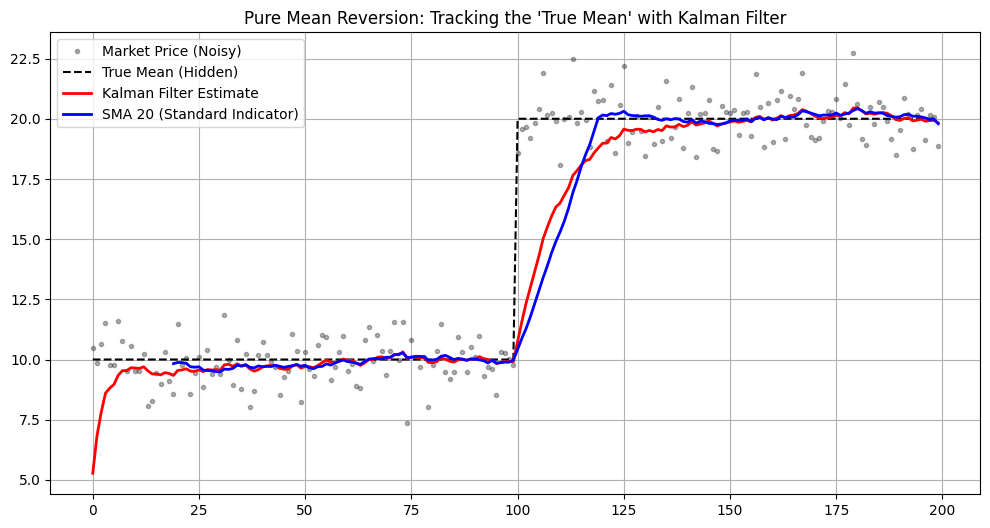

In [5]:
# --- 4. Plot กราฟ ---
plt.figure(figsize=(12, 6))
plt.plot(prices, 'k.', alpha=0.3, label='Market Price (Noisy)')
plt.plot(true_mean, 'k--', label='True Mean (Hidden)')
plt.plot(kalman_means, 'r-', linewidth=2, label='Kalman Filter Estimate')
plt.plot(sma_20, 'b-', linewidth=2, label='SMA 20 (Standard Indicator)')

plt.title("Pure Mean Reversion: Tracking the 'True Mean' with Kalman Filter")
plt.legend()
plt.grid(True)
plt.show()

อธิบายผลลัพธ์ (Code Explanation)
เมื่อคุณรันโค้ดนี้ ให้สังเกตที่จุด Step ที่ 100 (จุดที่กราฟกระโดดจาก 10 ไป 20):

1. เส้นสีน้ำเงิน (SMA 20): จะค่อยๆ ไต่ขึ้นอย่างเชื่องช้า (Lag) เพราะมันยังเฉลี่ยค่าเก่าๆ จากช่วงก่อนหน้ามาด้วย ทำให้เรา "เห็นเทรนด์ช้ากว่าความเป็นจริง"

2. เส้นสีแดง (Kalman Filter): จะดีดตัวขึ้นหาค่าเฉลี่ยใหม่ (20) ได้เร็วกว่ามาก และเมื่อราคาเริ่มนิ่ง เส้น Kalman ก็จะนิ่งตาม

3. นัยสำคัญ:

    - ถ้าใช้ Mean Reversion Strategy: Signal = Price - Mean

    - ถ้าใช้ SMA เป็น Mean: ราคาตลาดไป 20 แล้ว แต่ SMA ยังอยู่ 15 -> คุณจะคิดว่าราคา "แพงเกินไป" (Overbought) และสั่ง Short สวนเทรนด์ -> ขาดทุน

    - ถ้าใช้ Kalman เป็น Mean: เส้นแดงตามราคาไปติดๆ -> System จะรู้ว่านี่คือ "ค่ากลางใหม่" ไม่ใช่ Overbought -> รอดตัว

Use Cases & Risk (ข้อควรระวัง)

การใช้ Kalman Filter กับ Mean Reversion Strategy มีจุดตายที่ตัวแปร $Q$ (Process Noise) ในโค้ด

- ถ้าปรับ Q ต่ำเกินไป: เส้น Kalman จะแข็งทื่อเหมือน SMA (ปรับตัวช้า)
- ถ้าปรับ Q สูงเกินไป: เส้น Kalman จะวิ่งตามราคาตลาดทุกเม็ด (กลายเป็นไม่มี Mean Reversion เลย เพราะ Price - Mean จะเท่ากับ 0 ตลอด)

Quant Trick: เรามักจะไมใช้ $Q$ คงที่ แต่จะใช้ Adaptive Q (เช่น ช่วงงบออก หรือ Volatility สูง ให้เพิ่มค่า Q เพื่อให้ Mean ปรับตัวไวขึ้น)

## สร้าง Trading Logic ด้วย Kalman Filte

แนวคิด (Logic)

$$Signal = Price - KalmanMean$$
$$Z\text{-}Score = \frac{Signal}{RollingStdDev(Signal)}$$

- Long Entry: Z-Score < -2 (ราคาถูกกว่าค่าเฉลี่ย Kalman มากผิดปกติ)
- Short Entry: Z-Score > 2 (ราคาแพงกว่าค่าเฉลี่ย Kalman มากผิดปกติ)
- Exit: Z-Score กลับมาที่ 0 (ราคากลับสู่สภาวะสมดุล)

### Code Implementation

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# --- Reuse Kalman Class (จาก Step ที่แล้ว) ---
class LocalLevelKalmanFilter:
    def __init__(self, R, Q):
        self.R = R 
        self.Q = Q
        self.state_mean = 0  
        self.state_covariance = 1 

    def update(self, measurement):
        prediction = self.state_mean
        prediction_covariance = self.state_covariance + self.Q
        K = prediction_covariance / (prediction_covariance + self.R)
        self.state_mean = prediction + K * (measurement - prediction)
        self.state_covariance = (1 - K) * prediction_covariance
        return self.state_mean

In [ ]:
# --- 1. สร้างข้อมูลจำลอง (Synthetic Data with Mean Reversion) ---
np.random.seed(99)
n = 300
# สร้างราคาแบบ OU Process ให้แกว่งรอบๆ 100
prices = []
x = 100
for _ in range(n):
    # Mean Reverting to 100 with volatility
    x = x + 0.3 * (100 - x) + np.random.normal(0, 2) 
    prices.append(x)
prices = pd.Series(prices)

In [ ]:
# --- 2. คำนวณ Kalman Mean ---
kf = LocalLevelKalmanFilter(R=1.0, Q=0.05) # Q=0.05 ให้ปรับตัวได้บ้าง
kalman_means = pd.Series([kf.update(p) for p in prices])

In [10]:
# --- 3. สร้าง Signal (Z-Score) ---
# Spread คือส่วนต่างระหว่างราคากับ Kalman Mean
spread = prices - kalman_means

# คำนวณ Rolling Standard Deviation ของ Spread (ใช้ Window สั้นๆ เพื่อจับ Volatility ปัจจุบัน)
rolling_std = spread.rolling(window=30).std()

# คำนวณ Z-Score
z_score = spread / rolling_std

In [11]:
# --- 4. สร้างจุด Buy/Sell (Vectorized Backtest แบบง่าย) ---
# Entry Threshold = 2.0, Exit = 0
long_signals = (z_score < -2.0)
short_signals = (z_score > 2.0)
exit_signals = (abs(z_score) < 0.5) # ออกเมื่อใกล้ 0

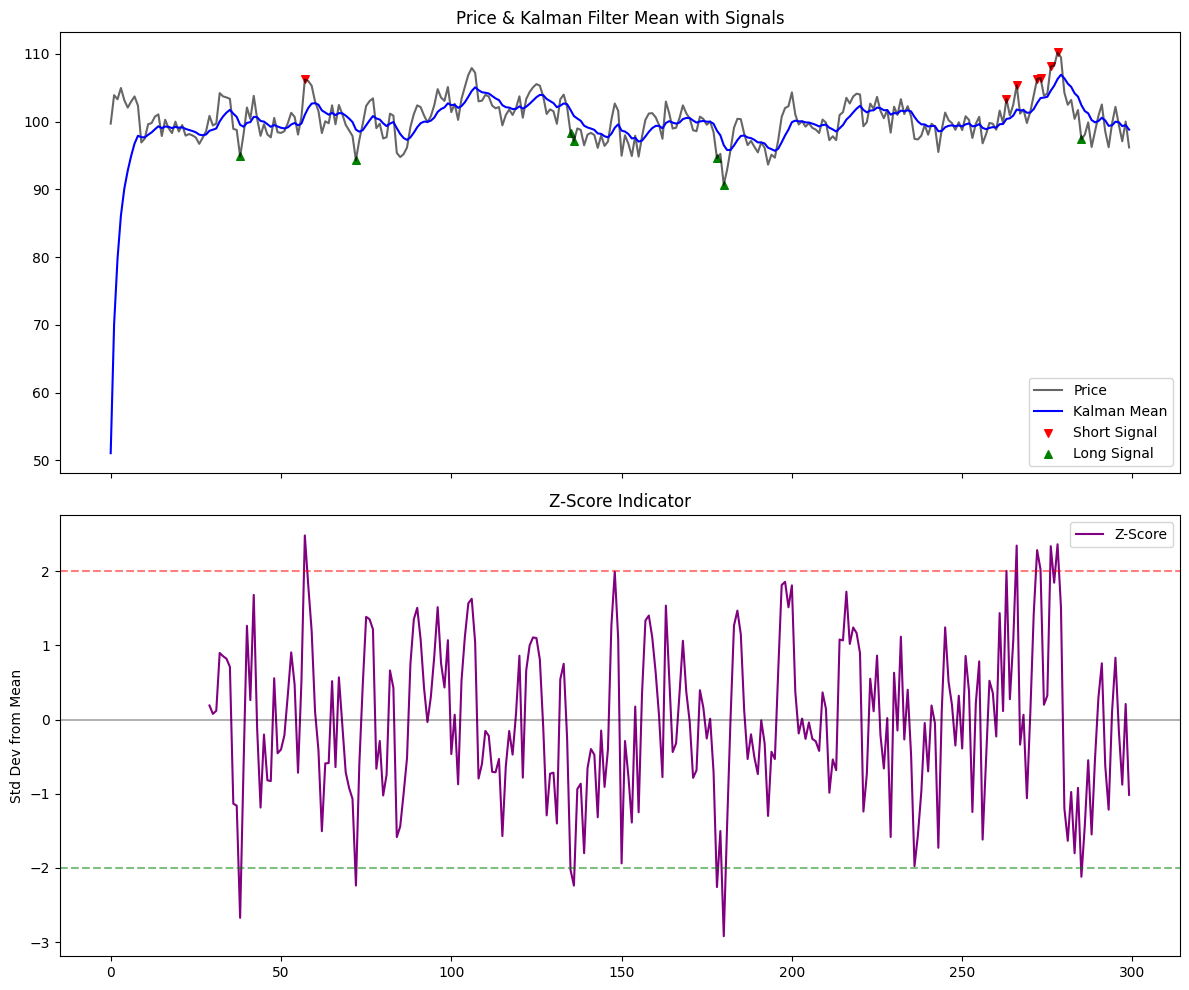

In [12]:
# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Price vs Kalman Mean
ax1.plot(prices, label='Price', color='black', alpha=0.6)
ax1.plot(kalman_means, label='Kalman Mean', color='blue')
# จุดที่ Short (สีแดง)
ax1.scatter(prices.index[short_signals], prices[short_signals], 
            color='red', marker='v', s=30, label='Short Signal')
# จุดที่ Long (สีเขียว)
ax1.scatter(prices.index[long_signals], prices[long_signals], 
            color='green', marker='^', s=30, label='Long Signal')
ax1.set_title('Price & Kalman Filter Mean with Signals')
ax1.legend()

# Plot 2: Z-Score
ax2.plot(z_score, label='Z-Score', color='purple')
ax2.axhline(2.0, color='red', linestyle='--', alpha=0.5)
ax2.axhline(-2.0, color='green', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_title('Z-Score Indicator')
ax2.set_ylabel('Std Dev from Mean')
ax2.legend()

plt.tight_layout()
plt.show()

สิ่งที่ควรสังเกตในกราฟ:
1. Smart Mean: เส้นสีน้ำเงิน (Kalman) ไม่ได้วิ่งผ่ากลางกราฟทื่อๆ แต่จะขยับหนีเมื่อราคากระชากแรงๆ ช่วยลด False Signal ได้ดีกว่า MA

2. Entry Points: จุดสามเหลี่ยม (Buy/Sell) จะเกิดขึ้นเมื่อราคา "ดีด" ออกจากเส้น Kalman อย่างรุนแรง (Z-Score ทะลุ 2)

3. Adaptive Volatility: สังเกตว่าเราใช้ spread / rolling_std การหารด้วย Rolling Std ช่วยให้ Threshold ของเราปรับยืดหดตามความผันผวนของตลาดได้เอง (เหมือน Bollinger Bands)